In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score
from torch.nn import functional as F
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

from domain_shift.core.config import settings
from domain_shift.CycleGAN.triplet_data_loader import get_data_loader
from domain_shift.CycleGAN.triplet_models import CycleGAN
from domain_shift.data_extraction.process_DRIAMS import DRIAMS_bin_to_df

In [2]:
torch.cuda.is_available()

True

In [3]:
# Load the data
driams_1 = DRIAMS_bin_to_df(settings.DRIAMS_D_PATH)
driams_2 = DRIAMS_bin_to_df(settings.DRIAMS_C_PATH)

In [4]:
# Combine the 'species' columns from both datasets
combined_species = pd.concat([driams_1['species'], driams_2['species']])

# Find the most represented species across both datasets
species_counts = combined_species.value_counts()
top_species = species_counts.index[:2]
top_species = top_species.tolist()
top_species

['Escherichia coli', 'Staphylococcus aureus']

In [5]:
# Show the distribution of the most represented species in each dataset
driams_1['species'].value_counts()[top_species], \
driams_2['species'].value_counts()[top_species]

(species
 Escherichia coli         2013
 Staphylococcus aureus    2174
 Name: count, dtype: int64,
 species
 Escherichia coli         927
 Staphylococcus aureus    738
 Name: count, dtype: int64)

In [6]:
# Filter by the 4 species with most representation
filtered_driams_1 = driams_1[driams_1["species"].isin(top_species)]
filtered_driams_2 = driams_2[driams_2["species"].isin(top_species)]

In [7]:
# Split into training and testing sets
driams_1_train, driams_1_val= train_test_split(filtered_driams_1, test_size=0.2, random_state=42, stratify=filtered_driams_1["species"])
driams_2_train, driams_2_val = train_test_split(filtered_driams_2, test_size=0.2, random_state=42, stratify=filtered_driams_2["species"])
len(driams_1_train), len(driams_1_val), len(driams_2_train), len(driams_2_val)

(3349, 838, 1332, 333)

In [8]:
# Get the data loaders
# driams_1_train_data_loader = get_data_loader(driams_1_train)
# driams_2_train_data_loader = get_data_loader(driams_2_train)
# driams_1_val_data_loader = get_data_loader(driams_1_val)
# driams_2_val_data_loader = get_data_loader(driams_2_val)

# print("DataLoader 1 train length:", len(driams_1_train_data_loader))
# print("DataLoader 2 train length:", len(driams_2_train_data_loader))

In [9]:
# Get the data loaders to overfit
driams_1_train_data_loader = get_data_loader(filtered_driams_1)
driams_2_train_data_loader = get_data_loader(filtered_driams_2)

print("DataLoader 1 train length:", len(driams_1_train_data_loader))
print("DataLoader 2 train length:", len(driams_2_train_data_loader))

DataLoader 1 train length: 4187
DataLoader 2 train length: 1665


In [ ]:
# Train the CycleGAN
print(torch.cuda.is_available())
cycle_gan = CycleGAN()
# cycle_gan.train(driams_1_train_data_loader, driams_2_train_data_loader, driams_1_val_data_loader, driams_2_val_data_loader)
cycle_gan.train(driams_1_train_data_loader, driams_2_train_data_loader)

True
Epoch 1/10 in 7943.183125972748s, Loss G: 1.0582, Loss D1: 0.0001, Loss D2: 0.0006, Avg GAN: 0.0181, Avg Cycle: 0.0016, Avg Identity: 0.0029, Triplet: 0.4829
	Validation loss improved, saving model.
Epoch 2/10 in 7987.632009506226s, Loss G: 1.0619, Loss D1: 0.0004, Loss D2: 0.0002, Avg GAN: 0.0051, Avg Cycle: 0.0005, Avg Identity: 0.0010, Triplet: 1.0319
	Validation loss did not improve, patience: 1
Epoch 3/10 in 8008.908661603928s, Loss G: 0.1905, Loss D1: 0.0003, Loss D2: 0.0002, Avg GAN: 0.0042, Avg Cycle: 0.0005, Avg Identity: 0.0009, Triplet: 0.9461
	Validation loss did not improve, patience: 2
Epoch 4/10 in 8003.044492483139s, Loss G: 0.1205, Loss D1: 0.0003, Loss D2: 0.0002, Avg GAN: 0.0016, Avg Cycle: 0.0005, Avg Identity: 0.0011, Triplet: 0.0412
	Validation loss improved, saving model.
Epoch 5/10 in 8024.690891981125s, Loss G: 0.1112, Loss D1: 0.0002, Loss D2: 0.0001, Avg GAN: 0.0007, Avg Cycle: 0.0005, Avg Identity: 0.0009, Triplet: 0.0329
	Validation loss improved, savi

In [11]:
# Calculate min and max values
gan_min, gan_max = min(cycle_gan.gan_error_loss), max(cycle_gan.gan_error_loss)
cycle_min, cycle_max = min(cycle_gan.cycle_error_loss), max(cycle_gan.cycle_error_loss)
triplet_min, triplet_max = min(cycle_gan.triplet_error_loss), max(cycle_gan.triplet_error_loss)

# Print min and max values
print(f"GAN Error Loss: Min = {gan_min}, Max = {gan_max}")
print(f"Cycle Error Loss: Min = {cycle_min}, Max = {cycle_max}")
print(f"Triplet Error Loss: Min = {triplet_min}, Max = {triplet_max}")

GAN Error Loss: Min = 0.0002518342102537347, Max = 0.018083232055739175
Cycle Error Loss: Min = 0.02201991893870123, Max = 0.08067777438683507
Triplet Error Loss: Min = 0.02497925661403104, Max = 1.0318677668386977


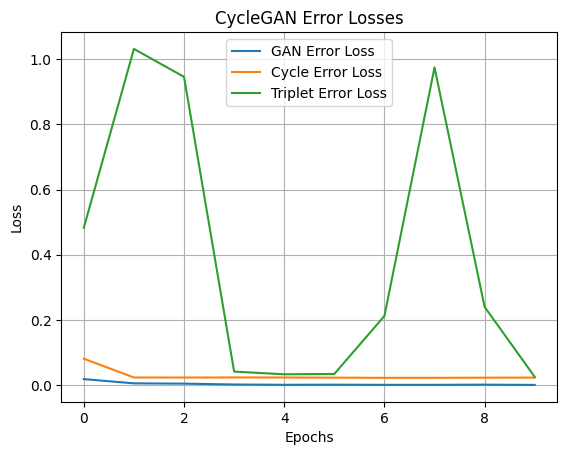

In [12]:
# Graph cycle_gan.identity_error_loss, cycle_gan.gan_error_loss, cycle_gan.cycle_error_loss
plt.plot(cycle_gan.gan_error_loss, label='GAN Error Loss')
plt.plot([error for error in cycle_gan.cycle_error_loss], label='Cycle Error Loss')
plt.plot([error for error in cycle_gan.triplet_error_loss], label='Triplet Error Loss')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('CycleGAN Error Losses')
plt.legend()
plt.grid(True)
plt.show()

In [13]:
# Train Random Forest on DRIAMS 1
X = np.vstack(filtered_driams_1["binned_6000"].values)
y = filtered_driams_1["species"].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestClassifier(n_estimators=100, random_state=42)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

f1_score(y_test, y_pred, average='weighted')

0.996420645478761

In [14]:
# Test the model on the filtered driams 2
X = np.vstack(filtered_driams_2["binned_6000"].values)
y = filtered_driams_2["species"].values

y_pred = rf.predict(X)

f1_score(y, y_pred, average='weighted')

1.0

In [ ]:
# Generate the synthetic data
synthetic_driams_2 = []
for index, data_anchor in filtered_driams_2.iterrows():
    binned_data = data_anchor["binned_6000"]

    # Convert to tensor if necessary
    if not isinstance(binned_data, torch.Tensor):
        binned_data = torch.tensor(binned_data, dtype=torch.float32)

    # Generate synthetic data
    output = cycle_gan.generator_2_to_1(binned_data.unsqueeze(0).to("cuda")).cpu().detach()
    
    # Flatten properly and append
    synthetic_driams_2.append(output.view(output.size(0), -1))  

# Stack tensors
synthetic_driams_2 = torch.cat(synthetic_driams_2)

# Test the model on the synthetic driams 2
X = synthetic_driams_2.numpy()
y = filtered_driams_2["species"].values

# Predict and compute F1 score
y_pred = rf.predict(X)
score = f1_score(y, y_pred, average='weighted')
print("F1 Score:", score)

F1 Score: 0.299363369009076


In [50]:
# Train Random Forest on DRIAMS 1
X = np.vstack(filtered_driams_2["binned_6000"].values)
y = filtered_driams_2["species"].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestClassifier(n_estimators=100, random_state=42)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

f1_score(y_test, y_pred, average='weighted')

1.0

In [51]:
# Test the model on the filtered driams 2
X = np.vstack(filtered_driams_1["binned_6000"].values)
y = filtered_driams_1["species"].values

y_pred = rf.predict(X)

f1_score(y, y_pred, average='weighted')

0.8582481947764672

In [53]:
# Generate the synthetic data
synthetic_driams_1 = []
for index, data_anchor in filtered_driams_1.iterrows():
    binned_data = data_anchor["binned_6000"]

    # Convert to tensor if necessary
    if not isinstance(binned_data, torch.Tensor):
        binned_data = torch.tensor(binned_data, dtype=torch.float32)

    # Generate synthetic data
    output = cycle_gan.generator_2_to_1(binned_data.unsqueeze(0).to("cuda")).cpu().detach()
    
    # Flatten properly and append
    synthetic_driams_1.append(output.view(output.size(0), -1))  

# Stack tensors
synthetic_driams_1 = torch.cat(synthetic_driams_1)

# Test the model on the synthetic driams 2
X = synthetic_driams_1.numpy()
y = filtered_driams_1["species"].values

# Predict and compute F1 score
y_pred = rf.predict(X)
score = f1_score(y, y_pred, average='weighted')
print("F1 Score:", score)

F1 Score: 0.3929957225074489


In [34]:
# Train PCA on the first dataset
X = np.vstack(filtered_driams_1["binned_6000"].values)
y = filtered_driams_1["species"].values

pca = PCA(n_components=3)
pca.fit(X)
pca_driams_1 = pca.transform(X)

In [35]:
# Test the model on the original driams 2
X = np.vstack(filtered_driams_2["binned_6000"].values)
y = filtered_driams_2["species"].values

# Transform the data using the PCA trained on the first dataset
pca_driams_2 = pca.transform(X)

In [38]:
# Test the model on the synthetic driams 2
X = np.vstack(synthetic_driams_2.numpy())
y = filtered_driams_2["species"].values

# Transform the data using the PCA trained on the first dataset
transformed_pca_driams_2 = pca.transform(X)

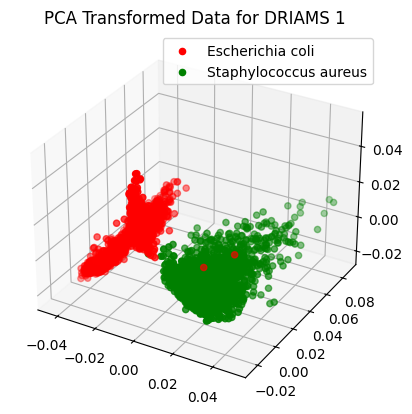

In [39]:
# Ensure you have PCA data and filtered species data
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
colors = ['red', 'green', 'blue', 'black', 'purple']

# Unique species
driams_1_labels = filtered_driams_1["species"].unique().tolist()

for i, species in enumerate(driams_1_labels):
    # Filter PCA data for the current species
    mask = filtered_driams_1["species"] == species
    plot_data = pca_driams_1[mask]

    # Scatter plot for this species
    ax.scatter(
        plot_data[:, 0],  # First PCA component
        plot_data[:, 1],  # Second PCA component
        plot_data[:, 2],  # Third PCA component
        c=colors[driams_1_labels.index(species)],  # Avoid index overflow
        label=species
    )

ax.legend()
ax.set_title("PCA Transformed Data for DRIAMS 1")
plt.show()


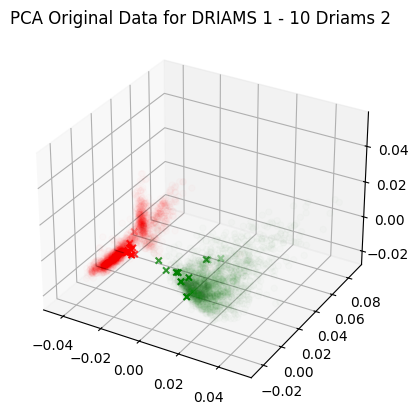

In [41]:
# Ensure you have PCA data and filtered species data
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Unique species
driams_1_labels = filtered_driams_1["species"].unique().tolist()

for i, species in enumerate(driams_1_labels):
    # Filter PCA data for the current species
    mask = filtered_driams_1["species"] == species
    plot_data = pca_driams_1[mask]

    # Scatter plot for this species
    ax.scatter(
        plot_data[:, 0],  # First PCA component
        plot_data[:, 1],  # Second PCA component
        plot_data[:, 2],  # Third PCA component
        c=colors[driams_1_labels.index(species)],  # Avoid index overflow
        label=species,
        alpha=0.01  # Set opacity to 50%
    )

    # Add 10 synthetic samples for each species
    mask = filtered_driams_2["species"] == species
    plot_data = pca_driams_2[mask][:10]
    
    # Scatter plot for this species
    ax.scatter(
        plot_data[:, 0],  # First PCA component
        plot_data[:, 1],  # Second PCA component
        plot_data[:, 2],  # Third PCA component
        c=colors[driams_1_labels.index(species)],  # Avoid index overflow
        label=species,
        marker='x'
    )

ax.set_title("PCA Original Data for DRIAMS 1 - 10 Driams 2")
plt.show()

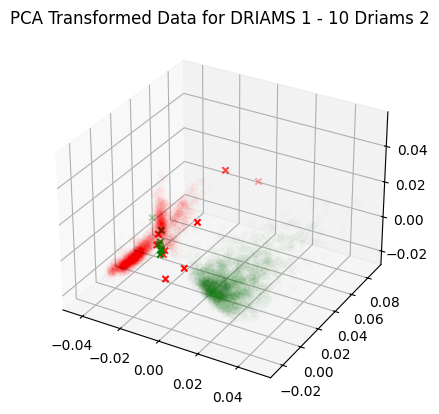

In [42]:
# Ensure you have PCA data and filtered species data
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Unique species
driams_1_labels = filtered_driams_1["species"].unique().tolist()

for i, species in enumerate(driams_1_labels):
    # Filter PCA data for the current species
    mask = filtered_driams_1["species"] == species
    plot_data = pca_driams_1[mask]

    # Scatter plot for this species
    ax.scatter(
        plot_data[:, 0],  # First PCA component
        plot_data[:, 1],  # Second PCA component
        plot_data[:, 2],  # Third PCA component
        c=colors[driams_1_labels.index(species)],  # Avoid index overflow
        label=species,
        alpha=0.01  # Set opacity to 50%
    )

    # Add 10 synthetic samples for each species
    mask = filtered_driams_2["species"] == species
    plot_data = transformed_pca_driams_2[mask][:10]

    # Scatter plot for this species
    ax.scatter(
        plot_data[:, 0],  # First PCA component
        plot_data[:, 1],  # Second PCA component
        plot_data[:, 2],  # Third PCA component
        c=colors[driams_1_labels.index(species)],  # Avoid index overflow
        label=species,
        marker='x'
    )

ax.set_title("PCA Transformed Data for DRIAMS 1 - 10 Driams 2")
plt.show()